# TAREA 3

In [182]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
import sklearn
import scipy 
from scipy.linalg import eigh, cholesky
from scipy.stats import norm
import linearmodels.panel as lmp
from pylab import plot, show, axis, subplot, xlabel, ylabel, grid
import semopy 
import seaborn as sns
from factor_analyzer import FactorAnalyzer
from sklearn.decomposition import PCA
from IPython.display import Image
from stepmix.stepmix import StepMix
from semopy import calc_stats

%matplotlib inline

<u> *Instrucciones* </u>

Los resultados de los ejericicios propuestos se deben entregar como un notebook por correo electronico a *juancaros@udec.cl* el dia 6/6 hasta las 21:00. Es importante considerar que el código debe poder ejecutarse en cualquier computadora con la data original del repositorio. Recordar la convencion para el nombre de archivo ademas de incluir en su documento titulos y encabezados por seccion. Utilizar la base de datos junaeb3.csv, el diccionario de datos es el siguiente:

- sexo: sexo del estudiante (1: mujer)
- edad: edad del estudiante (meses)
- imce: indice de masa corporal estandarizado (puntaje z)
- vive_padre: 1 si el padre vive en el hogar (2 indica que tiene mas de un padre)
- vive_madre: 2 si la madre vive en el hogar (2 indica que tiene mas de una madre)
- area: urbana=1, rural=0
- sk1: muestra afecto a padres (1: siempre - 5: nunca)
- sk2: muestra afecto a sus pares (1: siempre - 5: nunca)
- sk3: expresa sus sentimientos (1: siempre - 5: nunca)
- sk4: usa gestos para mostrar sentimientos (1: siempre - 5: nunca)
- sk5: juega con otros (1: siempre - 5: nunca)
- sk6: comparte sus cosas con otros (1: siempre - 5: nunca)
- sk7: es agresivo (1: siempre - 5: nunca)
- sk8: participa en juegos grupales (1: siempre - 5: nunca)
- sk9: hace preguntas a adultos (1: siempre - 5: nunca) 
- sk10: tiene interes por libros (1: siempre - 5: nunca) 
- sk11: tiene interes por su entorno (1: siempre - 5: nunca)
- sk12: juega a armar y desarmar cosas (1: siempre - 5: nunca) 
- sk13: tiene expresiones artisticas (1: siempre - 5: nunca) 
- act_fisica: frecuencia actividad fisica (1: nunca - 5: 5 o mas veces a la semana)
- educm: años de escolaridad de la madre
- educp: años de escolaridad del padre
- madre_work: si la madre trabaja (-1: labor domestica, 0: desempleada, 1: empleada)

## Preguntas:

### 1. Cargue la base de datos y realice los ajustes necesarios para su uso (missing values, recodificar variables, etcetera). Identifique los tipos de datos que se encuentran en la base, realice estadisticas descriptivas sobre las variables importantes (Hint: Revisar la distribuciones, datos faltantes, outliers, etc.) y limpie las variables cuando sea necesario.

**R:** Primero, se cargaron los datos para su análisis exploratorio. Se generaron distintos gráficos con el fin de examinar la distribución de las variables, identificar posibles valores atípicos (outliers) y visualizar la proporción de valores nulos (NaN) presentes en el conjunto de datos.
Posteriormente, se eliminaron los valores nulos y se creó una nueva columna que permitió analizar la distribución por rangos de edad de los niños, la cual fue representada mediante un gráfico de tipo pie chart. Además, se construyó una matriz de correlación para evaluar la relación entre las variables, observándose que ninguna de ellas presentaba una correlación significativa.

In [183]:
df = pd.read_csv('DATA/junaeb3.csv')

In [184]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
0,1,85,0.75,1,1,1,1,1,2,1,2,2,1,2,2,2,3,2,NaN,0,11.0,11,-1
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1
2,1,68,0.27,0,1,2,2,3,2,1,2,3,2,2,3,2,1,3,NaN,1,13.0,13,1
3,1,84,2.05,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0,1,17.0,15,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,1,1,3,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,1,1,2,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,1,1,1,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,2,1,2,1,2,1,1,2,2.0,1,17.0,15,1


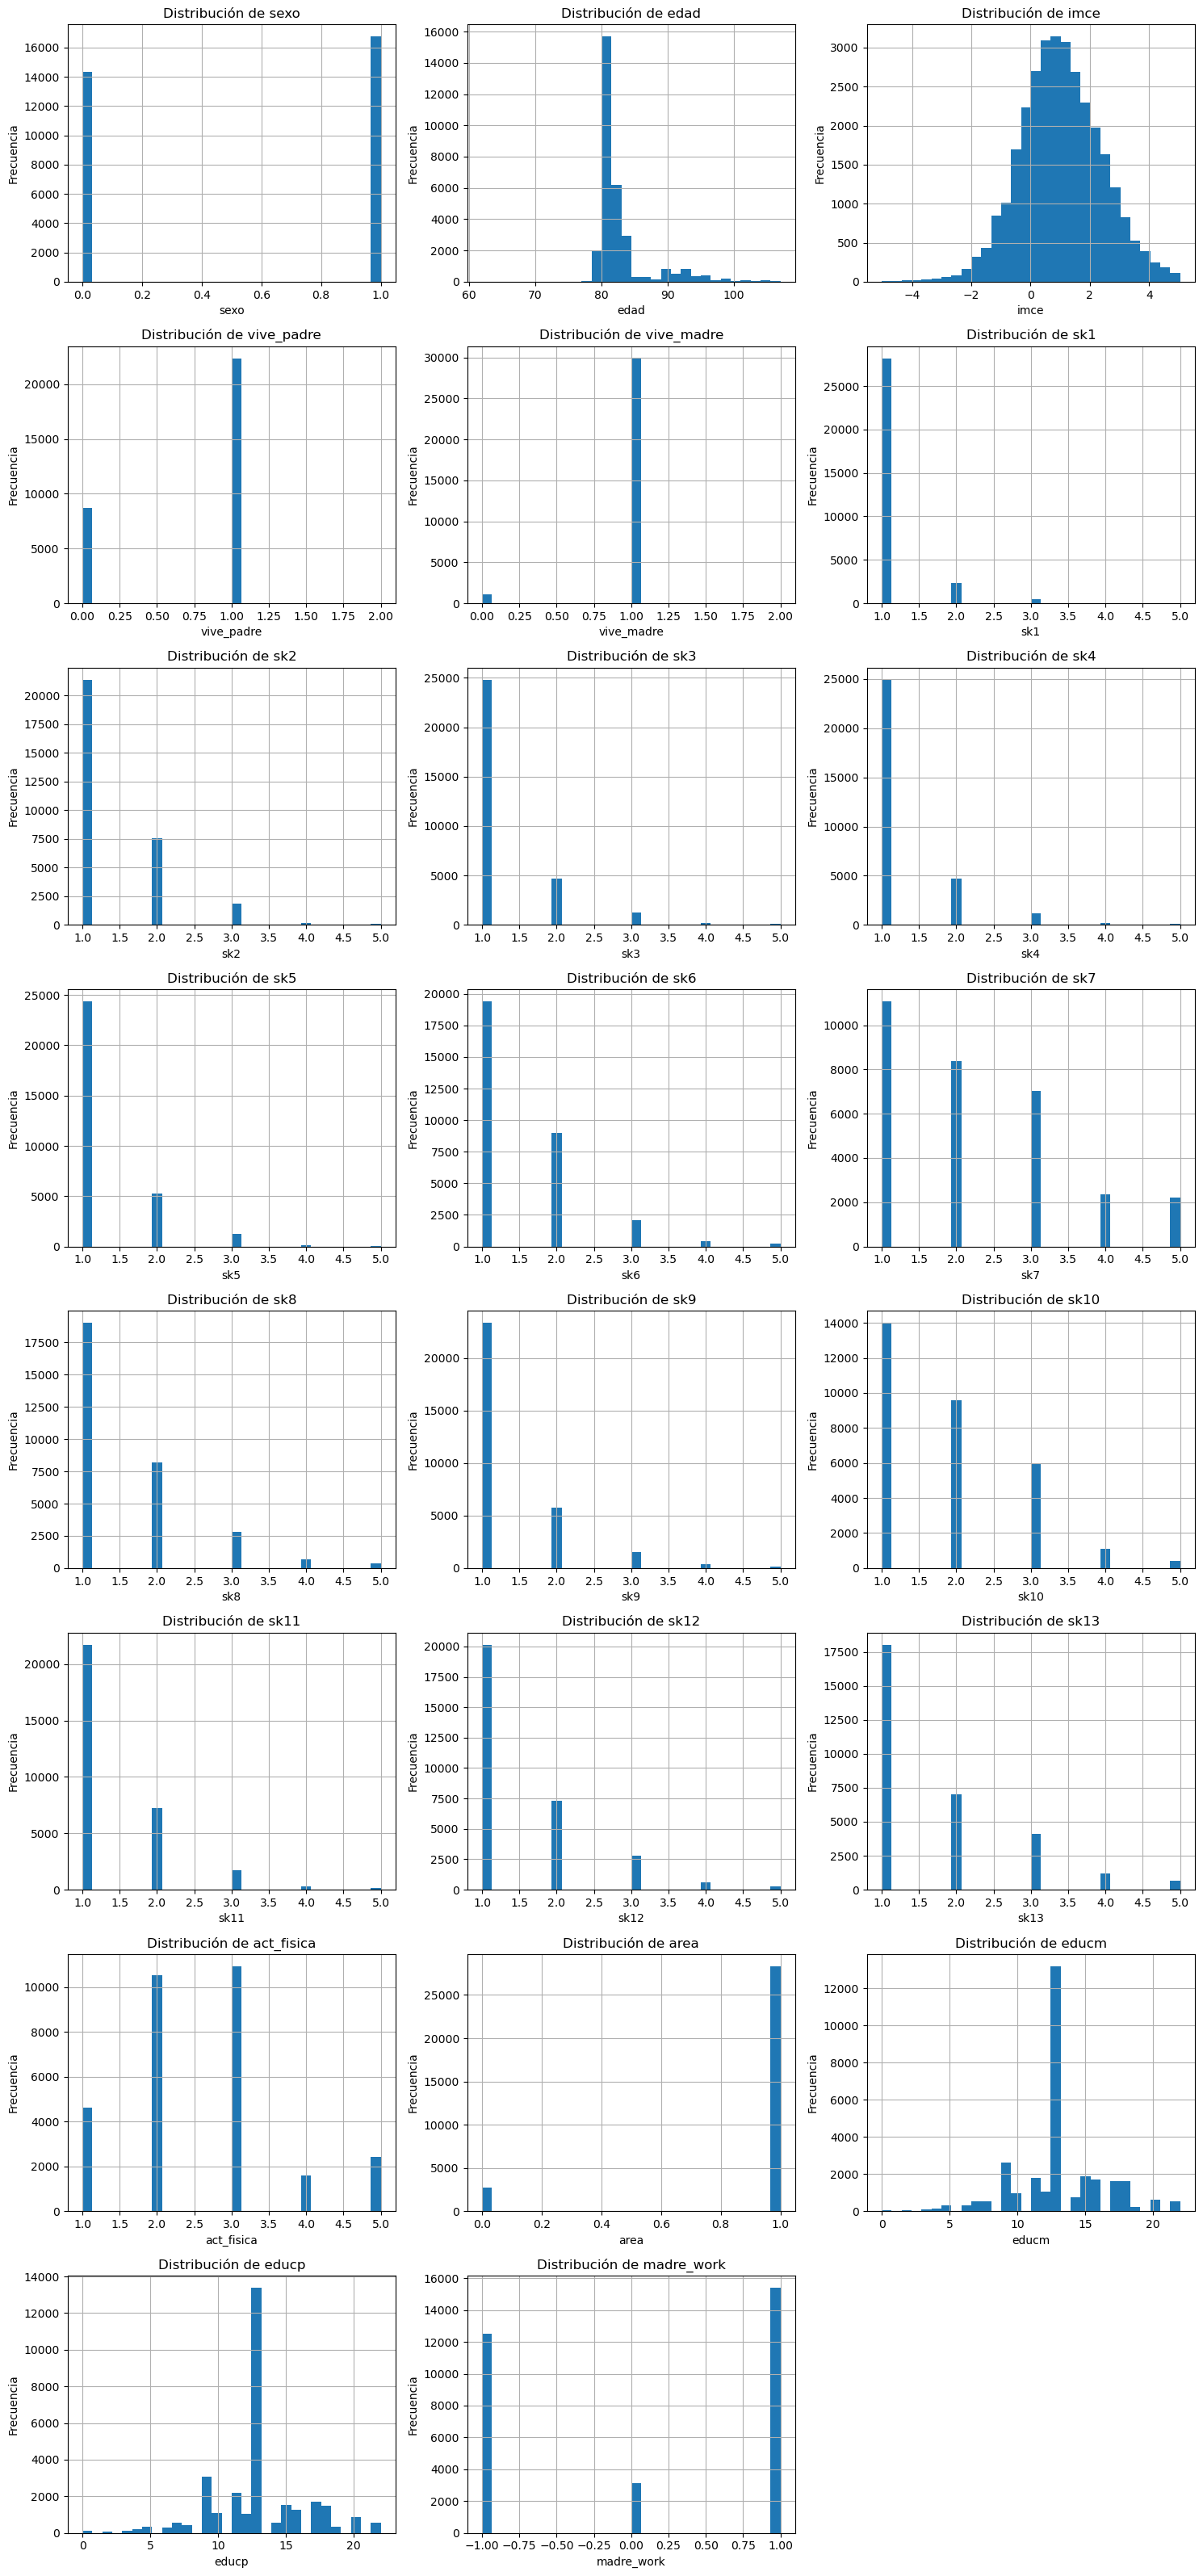

In [186]:
#Graficamos las distribuciones de las variables para facilitar su analisis
import math
columnas_numericas = (df).select_dtypes(include='number').columns

num_columnas = 3
num_graficos = len(columnas_numericas)
num_filas = math.ceil(num_graficos / num_columnas)

fig, axes = plt.subplots(num_filas, num_columnas, figsize=(num_columnas * 5, num_filas * 4))
axes = axes.flatten()

# Generar cada histograma
for i, col in enumerate(columnas_numericas):
    df[col].hist(ax=axes[i], bins=30)
    axes[i].set_title(f'Distribución de {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frecuencia')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


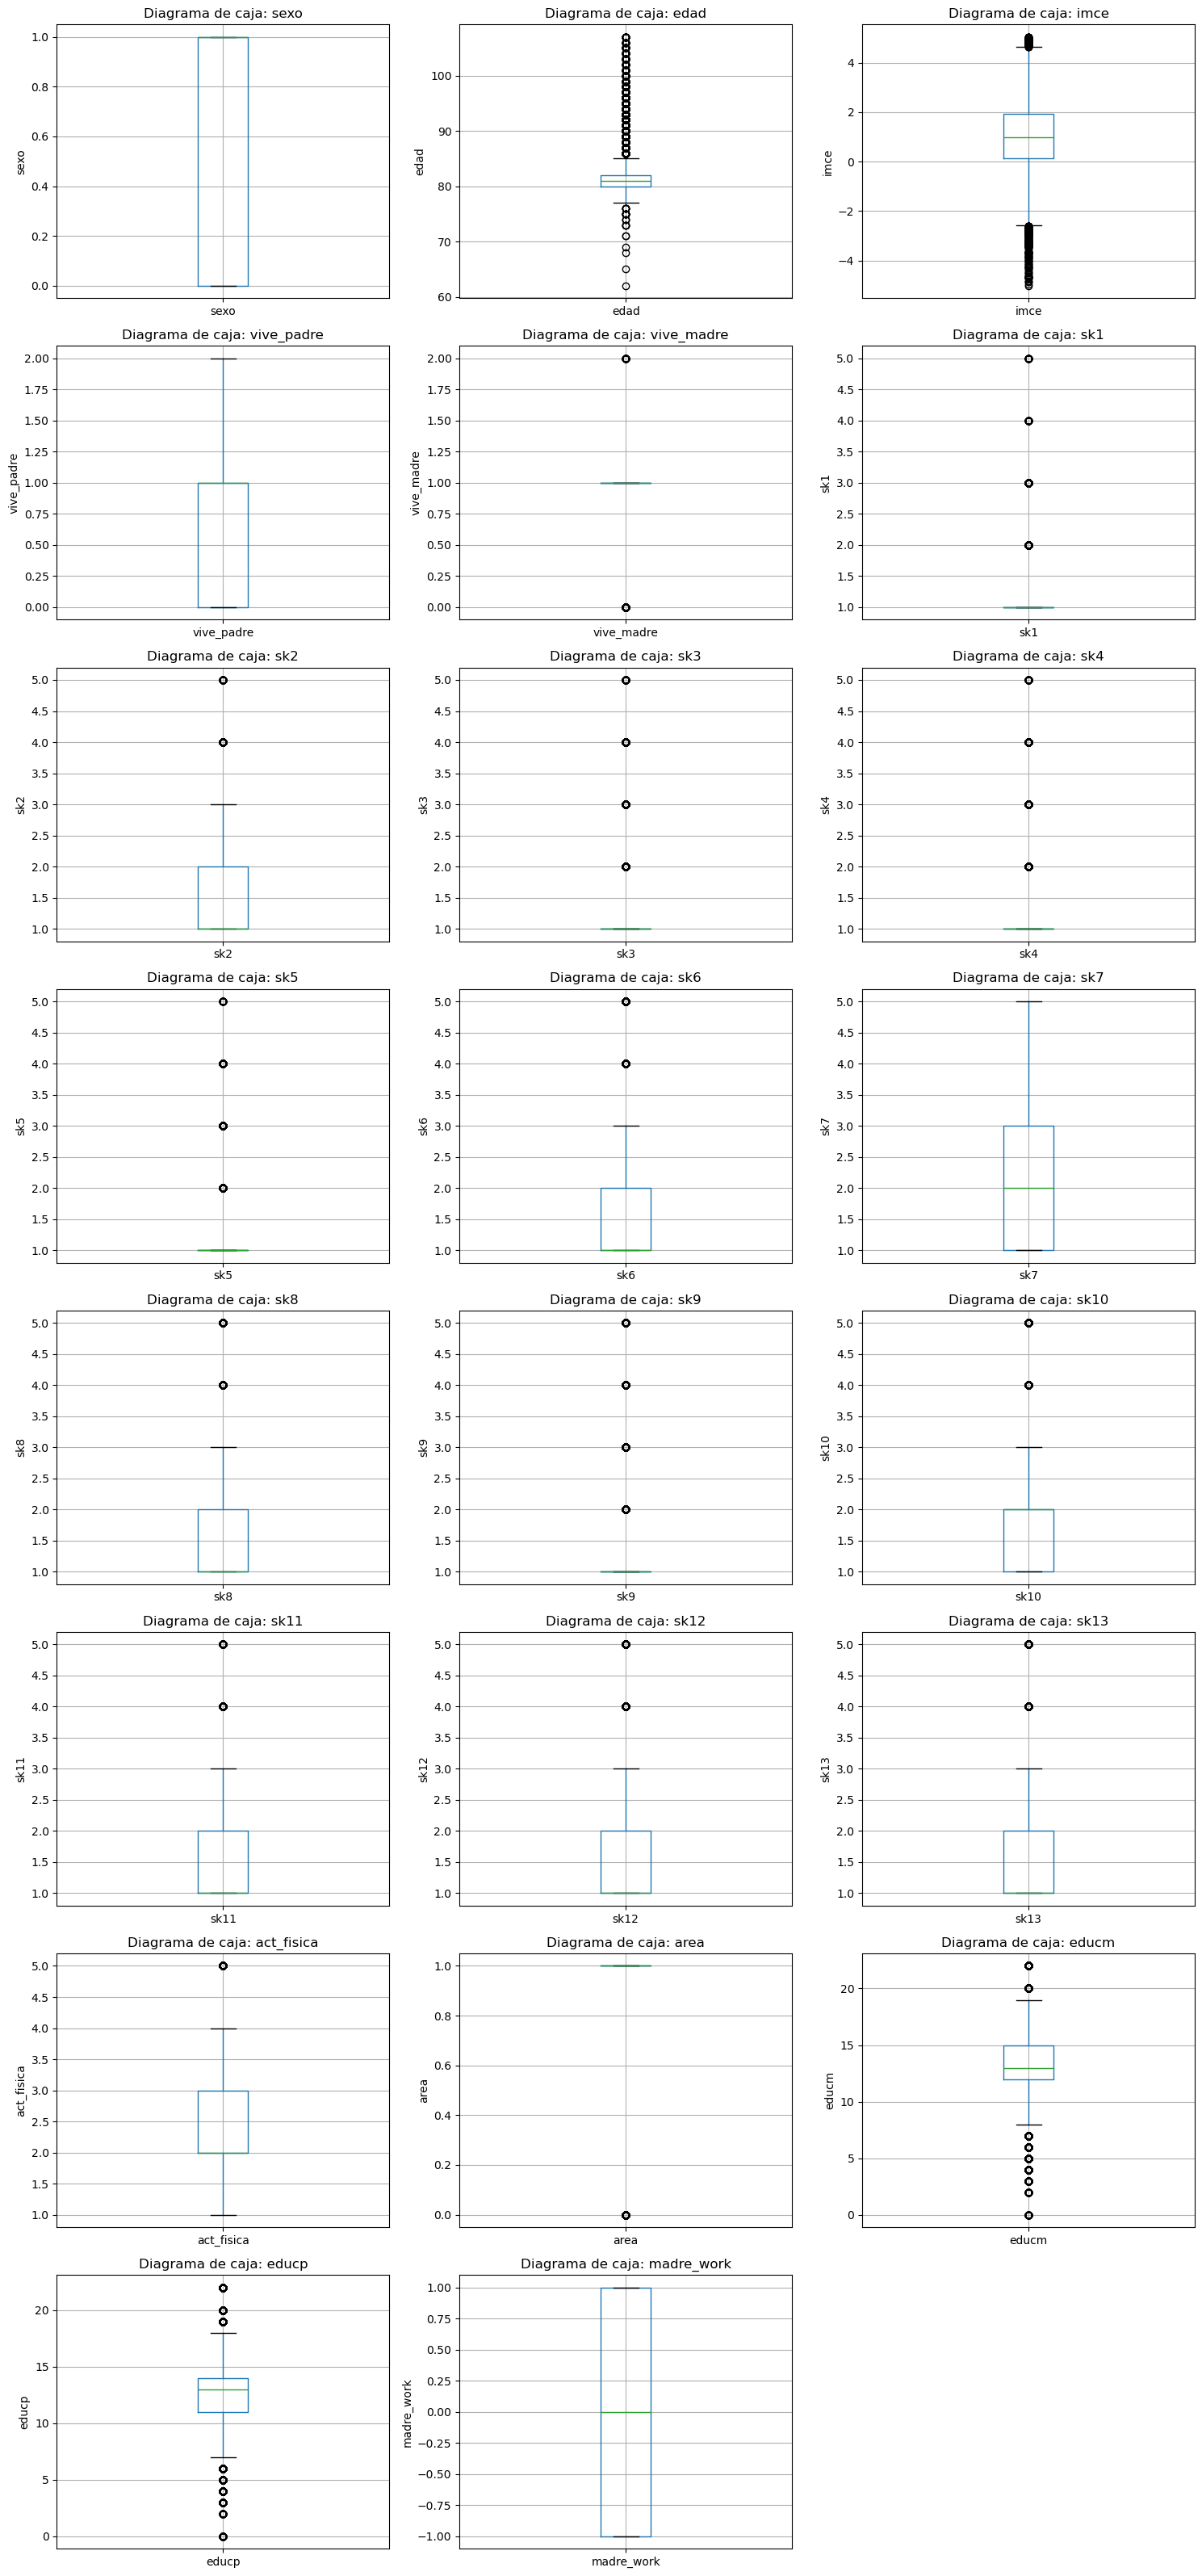

In [187]:
#Graficar con boxplot las variables para identificar outliers
#Y aun que se reconoce la existencia de estos mismos de todas formas se mantendran en el df para los futuros analisis
import math
columnas_numericas = (df).select_dtypes(include='number').columns

num_columnas = 3
num_graficos = len(columnas_numericas)
num_filas = math.ceil(num_graficos / num_columnas)
fig, axes = plt.subplots(num_filas, num_columnas, figsize=(num_columnas * 5, num_filas * 4))
axes = axes.flatten()

for i, col in enumerate(columnas_numericas):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(f'Diagrama de caja: {col}')
    axes[i].set_ylabel(col)

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

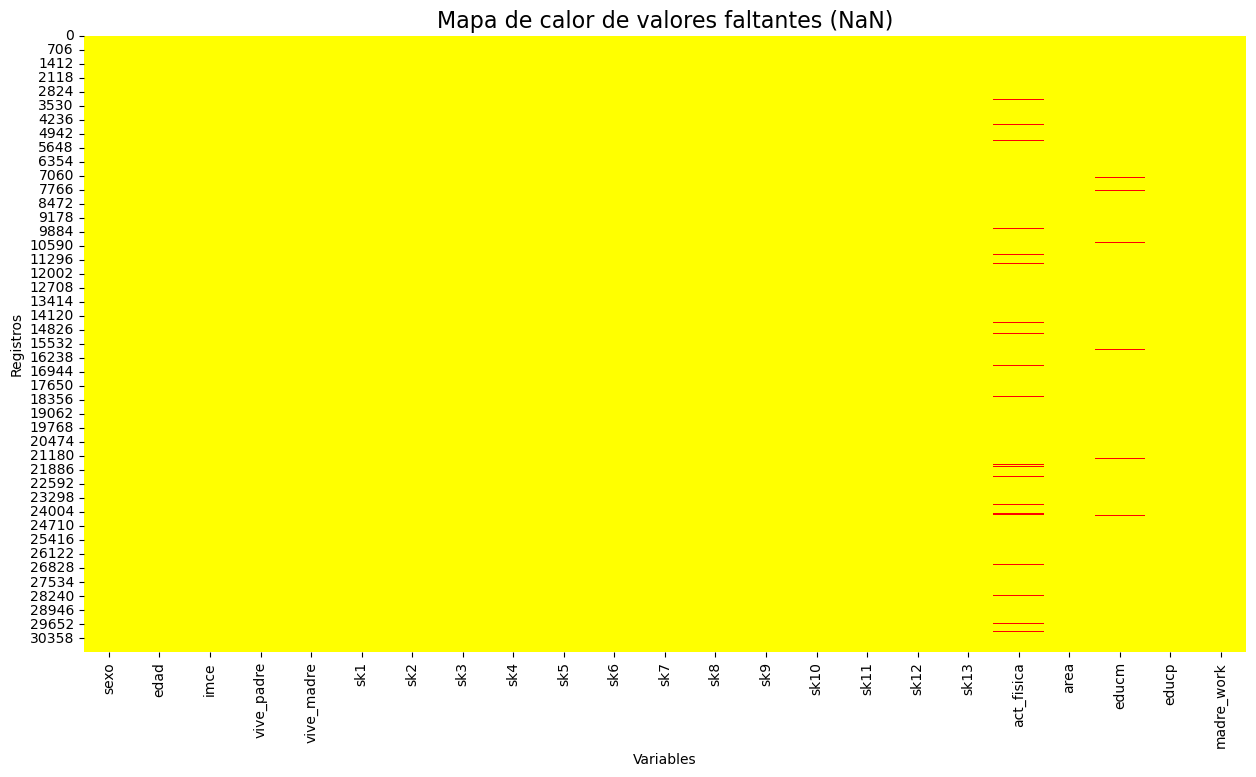

In [188]:
#Generamos un mapa de calor para identificar visualmente las variables con mas NaN
plt.figure(figsize=(15, 8))
sns.heatmap(df.isnull(), cbar=False, cmap=sns.color_palette(["yellow", "red"]))  # yellow = no NaN, red = NaN
plt.title("Mapa de calor de valores faltantes (NaN)", fontsize=16)
plt.xlabel("Variables")
plt.ylabel("Registros")
plt.show()

In [189]:
df=df.dropna()

In [190]:
df['años'] = df['edad'] / 12

C:\Users\HP Envy\AppData\Local\Temp\ipykernel_8856\4004682604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['años'] = df['edad'] / 12


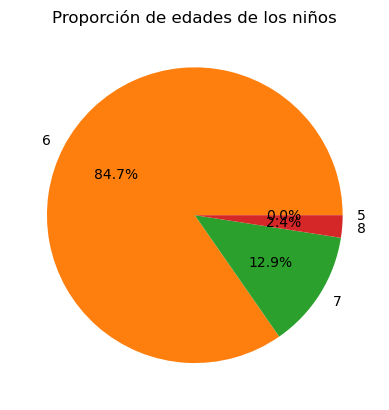

In [191]:
df['años'].astype(int).value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title("Proporción de edades de los niños")
plt.ylabel("")  # Opcional para quitar el eje Y
plt.show()


In [192]:
df=df.drop("años",axis=1)

<Axes: >

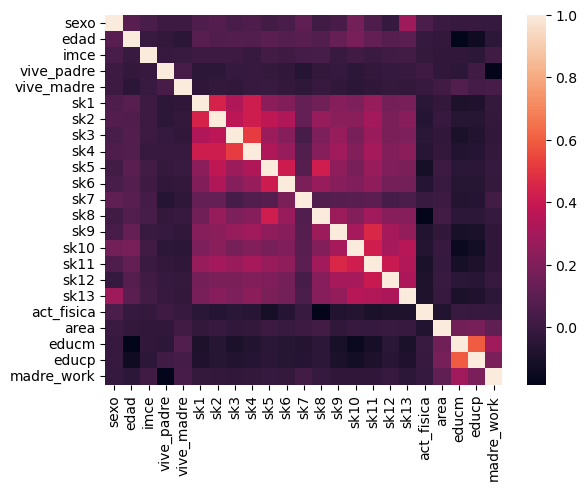

In [193]:
sns.heatmap(df.corr())

In [194]:
df

,sexo,edad,imce,vive_padre,vive_madre,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13,act_fisica,area,educm,educp,madre_work
1,0,76,0.71,0,1,1,1,1,1,1,1,4,1,1,1,1,1,1,5.0,0,8.0,8,1
3,1,84,2.05,1,1,1,1,1,1,1,1,2,1,1,1,1,1,1,2.0,1,16.0,12,-1
4,0,86,1.05,1,1,1,1,1,1,1,1,3,1,1,1,1,1,1,1.0,1,17.0,15,0
5,0,74,1.39,1,1,1,2,1,1,1,1,4,1,1,1,1,1,1,4.0,0,8.0,8,-1
6,1,91,2.75,1,1,1,1,1,2,2,2,3,2,3,3,3,2,2,2.0,1,20.0,19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31050,0,78,1.63,1,1,1,3,1,2,2,1,1,3,2,2,2,1,1,2.0,1,13.0,13,-1
31051,1,79,2.57,1,1,1,1,2,2,1,1,1,2,1,3,2,1,4,3.0,1,18.0,19,0
31052,0,78,2.12,1,1,1,1,1,1,1,1,1,1,1,3,1,1,1,3.0,1,13.0,9,1
31053,1,78,-0.43,1,1,1,1,1,1,2,2,1,2,1,2,1,1,2,2.0,1,17.0,15,1


### 2. A partir de las variables sk1-sk13 realice un EFA. En particular determine el numero optimo de factores y reporte las variables que se asocian a cada factor (usando los factor loadings). Tambien discuta si existen variables que no son informativas. (Hint: para realizar un EFA, todas las variables deben estar representatadas en el mismo sentido logico. Si una carateristica es negativa debe ser invertida en la escala, de tal forma que todas las variables representen aspectos positivos).***

**R:** Para el análisis, se comenzó generando un DataFrame que incluyera únicamente las variables sk1 a sk13. A continuación, se ajustó un modelo de análisis factorial al conjunto de datos, utilizando rotación varimax para facilitar la interpretación de los factores.
Se procedió a graficar los valores propios (eigenvalues) en función del número de factores, con el objetivo de evaluar cuántos factores retener. Siguiendo el criterio de Kaiser que sugiere conservar únicamente los factores con valores propios mayores a 1, se observó que visualmente podrían considerarse hasta cuatro factores. Sin embargo, dado que el cuarto valor se encuentra muy cerca del umbral, se optó por considerar que tres factores serían una mejor elección, tanto estadística como interpretativamente.

Posteriormente, se analizaron las cargas factoriales (loadings), las cuales indican el grado de relación entre cada variable original y los factores extraídos. Para identificar la estructura subyacente, se asignó cada variable al factor con el cual presentaba su mayor carga factorial.
A partir de este análisis, se determinó que:
- El Factor 1 agrupa las variables sk9, sk10, sk11, sk12 y sk13.
- El Factor 2 está compuesto por sk1, sk2, sk3, sk4 y sk8.
- El Factor 3 incluye sk5 y sk6.

La variable sk7 mostró cargas factoriales bajas en los tres factores, por lo que no fue asignada a ninguno de ellos, al no presentar una relación significativa con ninguno en particular

In [195]:
df1 = df[df.columns[pd.Series(df.columns).str.startswith(('sk'))]]

In [196]:
df1.describe()

,sk1,sk2,sk3,sk4,sk5,sk6,sk7,sk8,sk9,sk10,sk11,sk12,sk13
count,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000,29696.000000
mean,1.108533,1.386651,1.256802,1.250943,1.264749,1.483803,2.228415,1.550748,1.326307,1.844693,1.379108,1.495858,1.687298
std,0.379168,0.643343,0.575636,0.569647,0.558138,0.734547,1.209599,0.827738,0.655108,0.933154,0.660226,0.790316,0.979401
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,1.000000,2.000000,1.000000,1.000000,1.000000,2.000000,3.000000,2.000000,1.000000,2.000000,2.000000,2.000000,2.000000
max,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000


In [197]:
#Crear modelo de analisis factorial
fa = FactorAnalyzer(rotation='varimax').fit(df1)

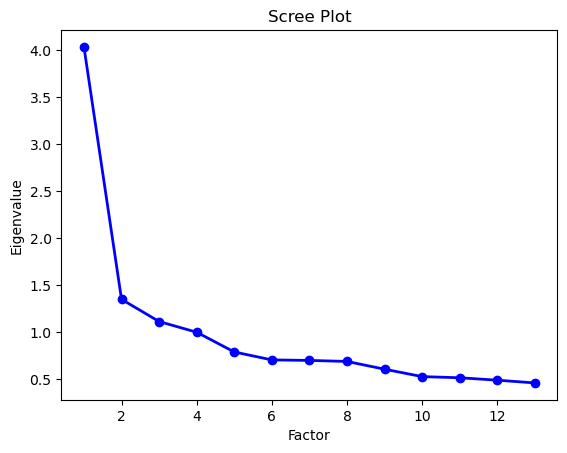

In [198]:
values = np.arange(1, 14)  # De 1 a 24
eigenvalues = pd.DataFrame(data=fa.get_eigenvalues())
plt.plot(values, eigenvalues.loc[0], 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Factor')
plt.ylabel('Eigenvalue')
plt.show()

In [199]:
np.set_printoptions(suppress=True, formatter={'float_kind':'{:f}'.format})
fa.loadings_

array([[0.171221, 0.540217, 0.151458],
       [0.174149, 0.512531, 0.354330],
       [0.179785, 0.587108, 0.161938],
       [0.195805, 0.685256, 0.194526],
       [0.121301, 0.214133, 0.716727],
       [0.162524, 0.203313, 0.486711],
       [0.070301, 0.074530, 0.146613],
       [0.269211, 0.097481, 0.478541],
       [0.495887, 0.205273, 0.201636],
       [0.555989, 0.121166, 0.127875],
       [0.665920, 0.206954, 0.202009],
       [0.524127, 0.109526, 0.141501],
       [0.480548, 0.151480, 0.131725]])

In [200]:
fa_test = FactorAnalyzer(rotation=None)
fa_test.fit(df1)
eigenvalues, _ = fa_test.get_eigenvalues()
print(eigenvalues)


[4.034140 1.350905 1.114858 1.001343 0.791246 0.707033 0.701430 0.690630
 0.608183 0.529379 0.517172 0.491397 0.462285]


In [201]:
loadings = pd.DataFrame(fa.loadings_, index=df1.columns,columns=["Factor 1", "Factor 2", "Factor 3"])
loadings


,Factor 1,Factor 2,Factor 3
sk1,0.171221,0.540217,0.151458
sk2,0.174149,0.512531,0.354330
sk3,0.179785,0.587108,0.161938
sk4,0.195805,0.685256,0.194526
sk5,0.121301,0.214133,0.716727
sk6,0.162524,0.203313,0.486711
sk7,0.070301,0.074530,0.146613
sk8,0.269211,0.097481,0.478541
sk9,0.495887,0.205273,0.201636
sk10,0.555989,0.121166,0.127875


### 3. Con los resultados de la Pregunta 2, graficamente indique si existen diferencias significativas en la distribucion de los factores usando las siguientes variables para caracterizar: sexo, area, imce y act_fisica (Hint: usar scatterplot de factores en pares, y ocupar la opcion 'hue' para agregar variables de caracterizacion). Que puede concluir de los resultados?

**R:** Primero, calculamos los puntajes factoriales utilizando el modelo de análisis factorial previamente ajustado, con el objetivo de poder representarlos gráficamente más adelante.
Luego, generamos una nueva columna categórica basada en el valor del IMCE. Para ello, definimos rangos que nos permitieran clasificar a cada individuo según su estado nutricional: Bajo peso extremo(-5 a -3), Bajo peso(-3 a -1), Normal(-1 a 1), Sobrepeso(1 a 3) y Obesidad(3 a 5)
Esta variable categórica (cat_imce) se creó a partir de cortes definidos sobre el IMCE, y fue añadida al DataFrame original. Posteriormente, seleccionamos únicamente las variables de caracterización relevantes: sexo, área, el IMCE categorizado y la actividad física, para formar un nuevo DataFrame. Esta información fue luego concatenada con los puntajes factoriales calculados anteriormente.

Finalmente, se generaron gráficos de dispersión emparejados (pairplots) para visualizar todas las combinaciones posibles entre los factores latentes, coloreando según cada variable de caracterización. Sin embargo, tras revisar los gráficos, no se observaron patrones evidentes de agrupación entre los grupos. En la mayoría de los casos, los puntos de diferentes categorías se encontraban dispersos o superpuestos, sin una separación clara que permitiera identificar estructuras o tendencias relevantes entre los factores y las variables de caracterización.

In [202]:
df2=df.drop(df1.columns,axis=1)

In [203]:
# Sólo pasar esas columnas a transform
factor_scores = fa.transform(df[df1.columns])
scores_df = pd.DataFrame(factor_scores, columns=["Factor 1", "Factor 2", "Factor 3"])

In [204]:
# Definir los límites y etiquetas
bins = [-float('inf'), -3,  -1, 1,3, float('inf')]
labels = ["Bajo peso extremo", "Bajo peso", "Normal", "Sobrepeso", "Obesidad"]  # etiquetas correspondientes

In [205]:
# Crear la nueva columna
df['cat_imce'] = pd.cut(df['imce'], bins=bins, labels=labels, right=False)

# Tomar las variables de caracterización (sexo, imce, etc.) de df original
vars_caracterizacion = df[["sexo", "area", "cat_imce", "act_fisica"]].reset_index(drop=True)
df=df.drop("cat_imce",axis=1)

# Concatenar
datos = pd.concat([scores_df.reset_index(drop=True), vars_caracterizacion], axis=1)
datos


,Factor 1,Factor 2,Factor 3,sexo,area,cat_imce,act_fisica
0,-0.711411,-0.311779,-0.401357,0,0,Normal,5.0
1,-0.708078,-0.316767,-0.485394,1,1,Sobrepeso,2.0
2,-0.709744,-0.314273,-0.443376,0,1,Sobrepeso,1.0
3,-0.787695,0.018257,-0.246966,0,0,Sobrepeso,4.0
4,1.759304,-0.071659,0.816447,1,1,Sobrepeso,2.0
...,...,...,...,...,...,...,...
29691,0.099888,0.686359,1.106135,0,1,Sobrepeso,2.0
29692,0.942463,0.625515,-0.667683,1,1,Sobrepeso,3.0
29693,-0.178377,-0.408693,-0.589694,0,1,Sobrepeso,3.0
29694,-0.427797,-0.611655,0.973490,1,1,Normal,2.0


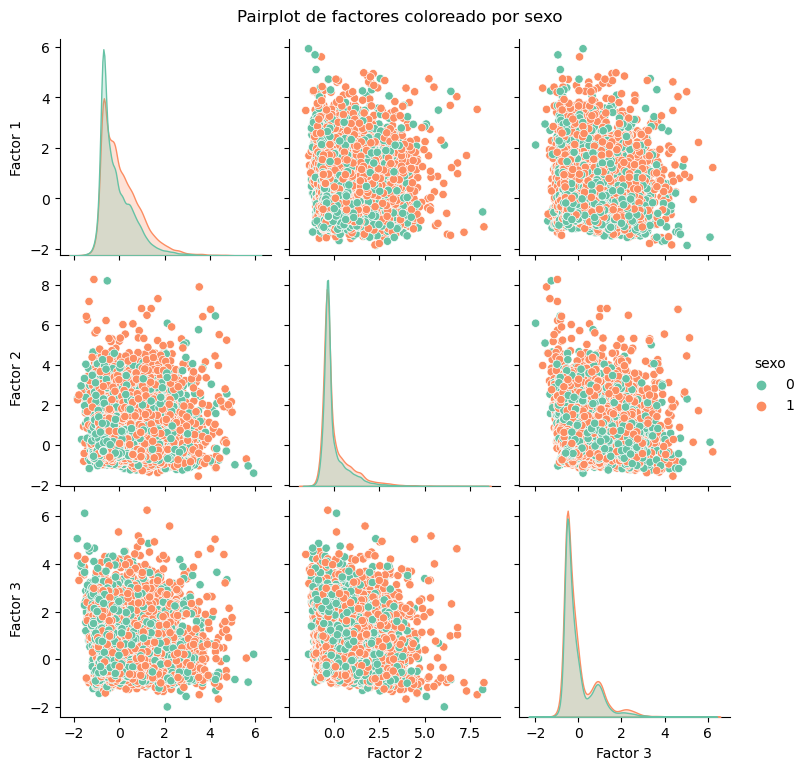

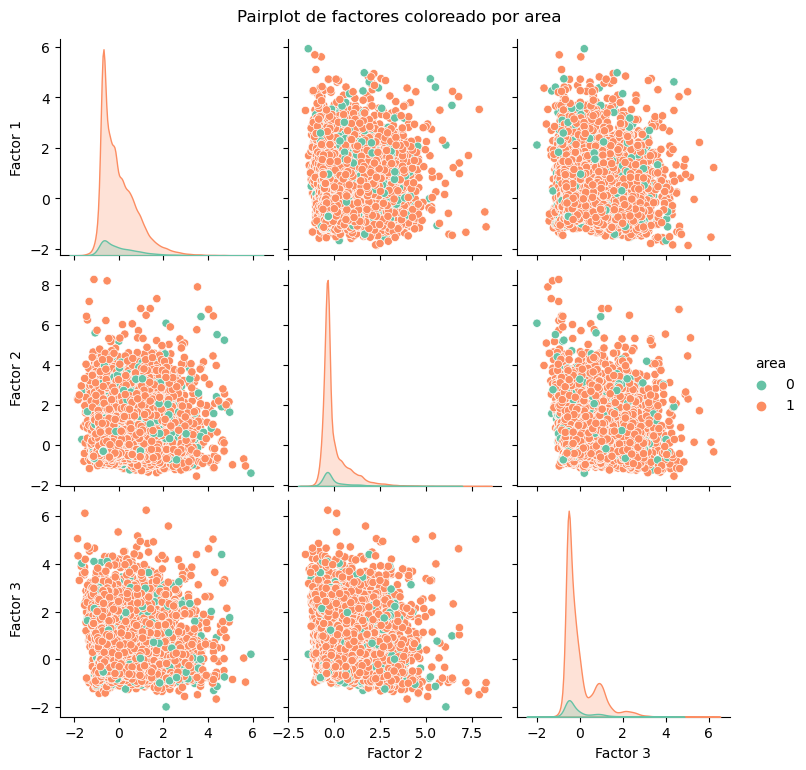

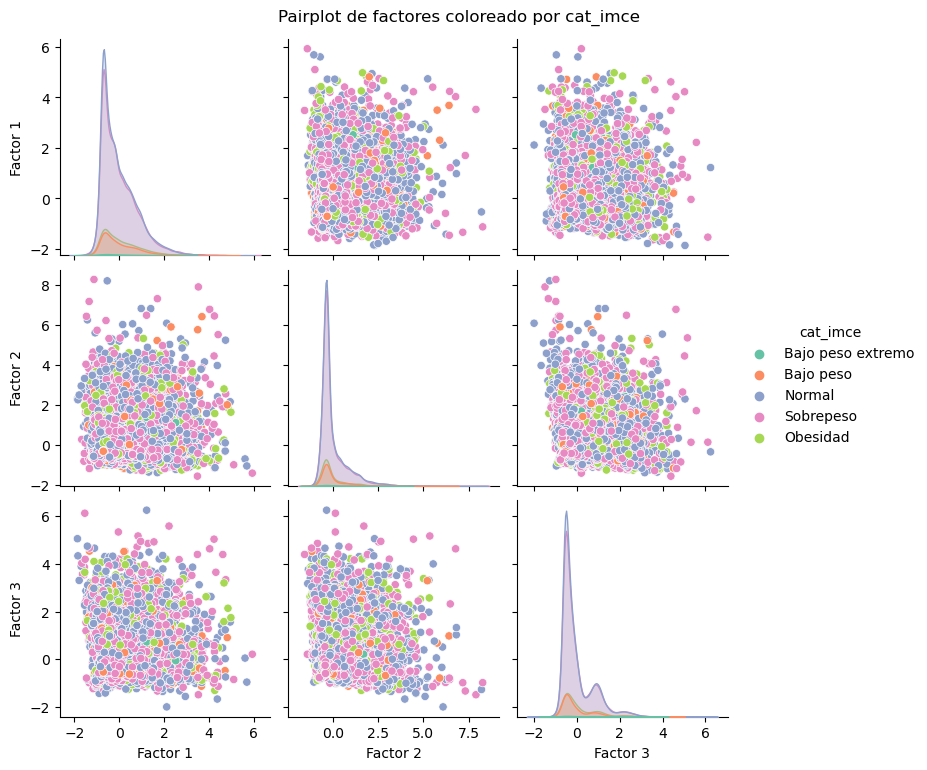

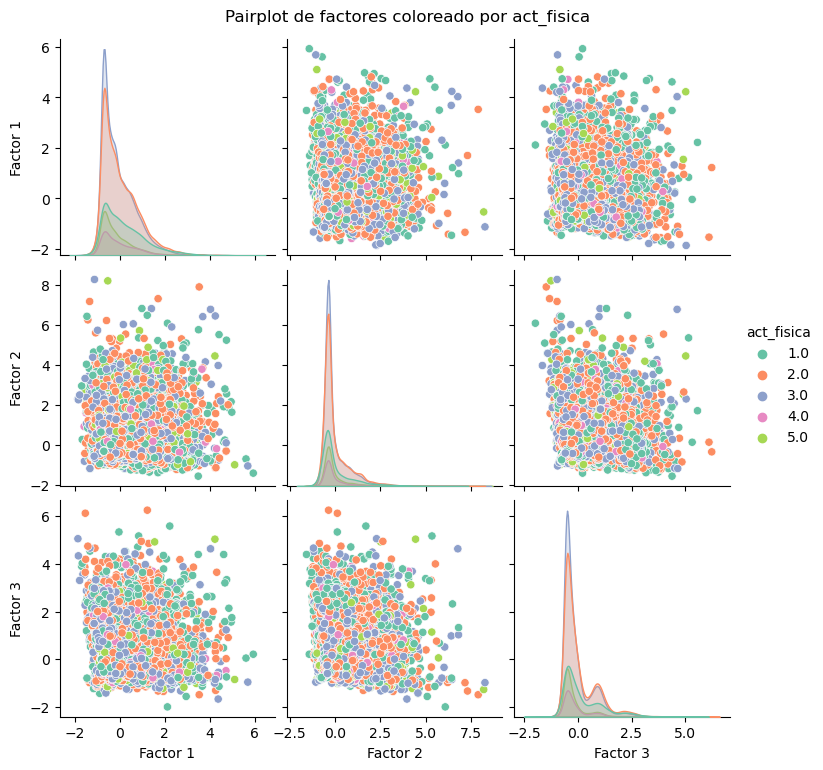

In [206]:

import seaborn as sns
import matplotlib.pyplot as plt

variables = ["sexo", "area", "cat_imce", "act_fisica"]
for var in variables:
    sns.pairplot(datos[["Factor 1", "Factor 2", "Factor 3", var]], hue=var, diag_kind="kde", palette="Set2")
    plt.suptitle(f"Pairplot de factores coloreado por {var}", y=1.02)
    plt.show()


### 4. Con los resultados obtenidos en la Pregunta 2, proponga un CFA donde cada variable solo se asocia con un factor. Entregue un nombre a cada factor que representa el concepto comun entre las variables incluidas. Reporte la importancia de cada medida (variable) a cada factor e indique la correlacion entre factores (loadings). 

**R:** Con base en los resultados obtenidos en la pregunta 2, proponemos un análisis factorial confirmatorio en el cual cada variable se asocia al factor correspondiente según la estructura mencionada anteriormente. De esta manera, el Factor 1, denominado Interes_Aprendizaje, está compuesto por las variables sk9, sk10, sk11, sk12 y sk13. El Factor 2, llamado Sentimiento, incluye las variables sk1, sk2, sk3, sk4 y sk8. Finalmente, el Factor 3, denominado Interaccion_Cooperativa, agrupa a las variables sk5 y sk6.
Primero, definimos el modelo de medición estableciendo los factores latentes, es decir, las variables no observadas que queremos medir. Luego, creamos una instancia del modelo SEM y lo ajustamos utilizando los datos del DataFrame.

Después, inspeccionamos los parámetros estimados del modelo para analizarlos más a fondo y calculamos las estadísticas de ajuste para evaluar la calidad del modelo.
Para determinar la importancia de cada variable en su respectivo factor, utilizamos los valores de estimate obtenidos con la función inspect. Por ejemplo, en el factor 1, las variables que tienen mayor peso son sk10, sk11 y sk13. En el factor 2, destaca especialmente sk2, seguido por sk4, aunque con menor peso. Por último, en el factor 3, la variable sk6 tiene una carga moderada.

En cuanto a la correlación entre factores, al analizar las covarianzas obtenidas con inspect, encontramos que la correlación entre el factor 1 y el factor 2 es de aproximadamente 0.63, lo que indica una relación moderadamente alta: están conectados pero no son iguales. La correlación entre el factor 3 y el factor 1 es más baja, compartiendo algo de varianza pero representando constructos diferenciados. Finalmente, la correlación más alta se da entre el factor 3 y el factor 2, con un valor cercano a 0.7. Aunque es una correlación alta que sugiere cierta redundancia, tiene sentido conceptual mantenerlos separados.

In [207]:
mod = """
# measurement model
exp =~ sk9 + sk10+ sk11+ sk12+ sk13 #Interes_Aprendizaje 
sent =~ sk1+ sk2+ sk3+ sk4+ sk8     #Expresion_Emocional
int =~ sk5+ sk6                     #Interaccion_Cooperativa
    """

model = semopy.Model(mod)
out=model.fit(df)
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 0.241
Number of iterations: 45
Params: 1.353 1.251 1.099 1.277 1.956 1.637 1.826 1.623 1.098 0.151 0.082 0.153 0.046 0.053 0.062 0.098 0.594 0.199 0.442 0.713 0.238 0.208 0.171 0.159 0.356 0.564 0.278


In [208]:
model.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,sk9,~,exp,1.000000,0.593288,-,-,-
1,sk10,~,exp,1.353086,0.563486,0.018621,72.664742,0.0
2,sk11,~,exp,1.251091,0.736457,0.014813,84.45829,0.0
3,sk12,~,exp,1.099294,0.540499,0.015583,70.543339,0.0
4,sk13,~,exp,1.276825,0.506584,0.018987,67.245693,0.0
5,sk1,~,sent,1.000000,0.565771,-,-,-
6,sk2,~,sent,1.956309,0.652328,0.024908,78.541572,0.0
7,sk3,~,sent,1.636954,0.610087,0.021694,75.456657,0.0
8,sk4,~,sent,1.825800,0.687630,0.022593,80.81389,0.0
9,sk8,~,sent,1.623222,0.420680,0.028131,57.701712,0.0


In [209]:
semopy.calc_stats(model)

,DoF,DoF Baseline,chi2,chi2 p-value,chi2 Baseline,CFI,GFI,AGFI,NFI,TLI,RMSEA,AIC,BIC,LogLik
Value,51,66,7149.463982,0.0,80903.16637,0.912188,0.911629,0.885638,0.911629,0.886361,0.068463,53.51849,277.585216,0.240755


In [210]:


estimates = model.inspect(mode='list', what="names", std_est=True)

# Filtrar solo las covarianzas entre factores (eta1, eta2, eta3)
factor_corrs = estimates[
    (estimates['op'] == '~~') &
    (estimates['lval'].str.contains('eta')) &
    (estimates['rval'].str.contains('eta')) &
    (estimates['lval'] != estimates['rval'])  # excluir varianzas
]

print(factor_corrs)


Empty DataFrame
Columns: [lval, op, rval, Estimate, Est. Std, Std. Err, z-value, p-value]
Index: []


In [211]:
# Primero obtén todas las varianzas y covarianzas entre factores
covs = estimates[
    (estimates['op'] == '~~') &
    (estimates['lval'].str.contains('eta')) &
    (estimates['rval'].str.contains('eta'))
]

# Crear diccionario para varianzas
vars_dict = {
    row['lval']: row['Estimate']
    for idx, row in covs.iterrows()
    if row['lval'] == row['rval']
}

# Calcular correlaciones manualmente
for idx, row in covs.iterrows():
    if row['lval'] != row['rval']:
        eta1, eta2 = row['lval'], row['rval']
        var1, var2 = vars_dict[eta1], vars_dict[eta2]
        corr = row['Estimate'] / (var1**0.5 * var2**0.5)
        print(f"Corr({eta1}, {eta2}) = {corr:.3f}")


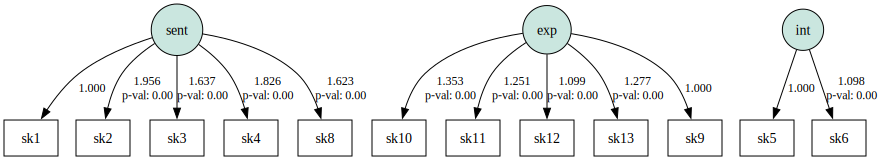

In [212]:
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

semopy.semplot(model, "4-semmodel.png")

### 5. Estime un modelo de clases latentes usando imce via StepMix. Determine el numero optimo de clases (clusters) y muestre las diferencias entre clusters graficamente. Que se puede concluir de los resultados?

**R:** Primero evaluamos modelos de clustering latente con distintos valores de 𝐾, K (número de clases latentes), con el objetivo de visualizar cómo varía el BIC y así estimar el número óptimo de clusters. Para ello, entrenamos modelos utilizando la técnica de StepMix con diferentes configuraciones.

En una primera instancia, entrenamos dos modelos con 3 clases latentes para comparar el impacto de la estructura de covarianza en el ajuste del modelo. El Modelo 1 utilizó una distribución gaussiana con covarianza diagonal (gaussian_diag), obteniendo un BIC de -771,883 y una entropía de 222, lo cual indica un modelo con buen ajuste y alta certeza en la asignación de clases. El Modelo 2, en cambio, utilizó una distribución gaussiana completa (gaussian), resultando en un BIC de 975,774.18 y una entropía de 7253, lo que sugiere un ajuste considerablemente peor y mayor incertidumbre en la clasificación.

Dado que el modelo con distribución gaussiana diagonal presenta un BIC más bajo y una entropía significativamente menor, se concluye que este ofrece un mejor equilibrio entre ajuste y parsimonia, siendo más adecuado para nuestros datos.

Una vez elegida la especificación adecuada del modelo, entrenamos un nuevo modelo con gaussian_diag utilizando únicamente la variable IMCE. Este modelo clasifica a las observaciones en tres clases latentes, asignando a cada persona el grupo al que pertenece según su IMCE. Esta clasificación permitirá interpretar posibles perfiles de individuos en base a su índice de masa corporal estandarizado.

Finalmente,al analizar y graficar las distribuciones por clase, podemos observar diferencias claras entre ellas. La clase 0, que agrupa casi el 50% de las observaciones, concentra la mayoría de sus puntajes en un rango entre 0 y 1, lo que indica valores relativamente regulares. Por otro lado, la clase 1 representa principalmente a los individuos con sobrepeso, con puntajes que comienzan alrededor de 1.5 y se extienden hacia valores más altos, abarcando aproximadamente el 41% de los datos. Finalmente, la clase 2, que es la menos representada con cerca del 10% de las observaciones, corresponde a valores bajos del índice, situándose en rangos cercanos a -1 o inferiores.

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:01<00:00,  1.65s/it, max_LL=-4.59e+5, max_avg_LL=-15.4]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.35s/it, max_LL=-4.56e+5, max_avg_LL=-15.4]


Fitting StepMix...


...

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.23s/it, max_LL=-4.55e+5, max_avg_LL=-15.3]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.25s/it, max_LL=-4.55e+5, max_avg_LL=-15.3]


<Axes: >

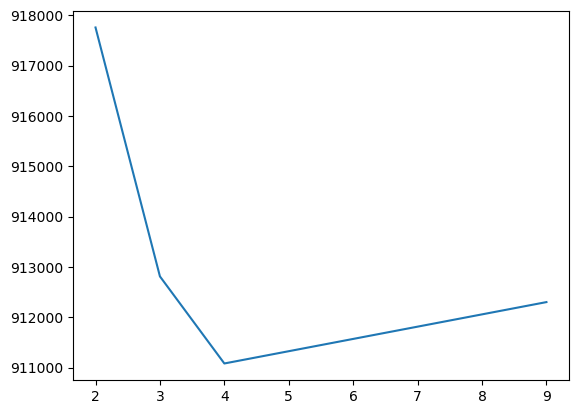

In [213]:
# Numero optimo de clusters
K = range(2, 10)
fits = []
BIC = []

for k in K:
    # entrenar modelo para k
    model = StepMix(n_components=k, measurement='gaussian', verbose=0, random_state=123).fit(df1)
    # agregar el moedlo a fits
    fits.append(model)
    
    # agregar silhouette score a scores
    BIC.append(model.sabic(df1))

sns.lineplot(x = K, y = BIC)    

In [214]:

# Numero optimo de clusters
K = range(2, 5)
fits = []
BIC = []

for k in K:
    # train the model for current value of k on training data
    model = StepMix(n_components=k, measurement='gaussian_diag', verbose=0, random_state=123).fit(df1)
    
    # append the model to fits
    fits.append(model)
    
    # Append the silhouette score to scores
    BIC.append(model.sabic(df1))

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.39it/s, max_LL=-9.9e+4, max_avg_LL=-3.33]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.39it/s, max_LL=3.96e+4, max_avg_LL=1.33]


Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.66s/it, max_LL=4.72e+4, max_avg_LL=1.59]


<Axes: >

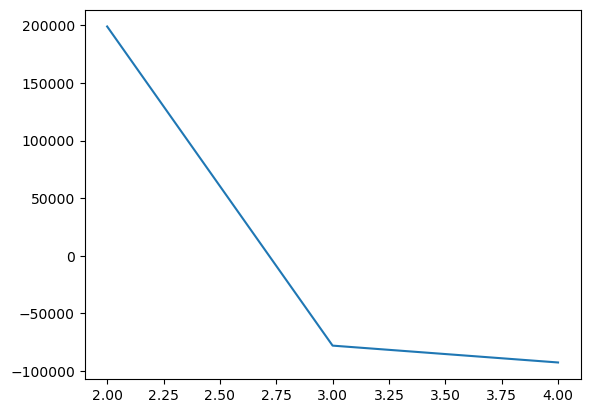

In [215]:
sns.lineplot(x = K, y = BIC)  

In [216]:
model1 = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df1)
#df1['pred']=model1.predict(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:00<00:00,  1.24it/s, max_LL=3.96e+4, max_avg_LL=1.33]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances sk1             0.2802  0.0000  0.0000
                      sk10            1.1124  0.9073  0.7517
                      sk11            0.8816  0.6087  0.2413
                      sk12            0.9519  0.7773  0.4758
                      sk13            1.2959  1.1109  0.7790
                      sk2             0.6157  0.5314  0.1995
                      sk3             0.7369  0.5372  0.0000
                      sk4             0.7700  0.5052  0.0000
                      sk5             0.6282  0.5098  0.1510
                      sk6             0.7606  0.6737  0.4015
                      sk7             1.4466  1.3335  1.4691
                      sk8             0.8876  0.8220  0.5522
                      sk9             0

In [217]:
model2 = StepMix(n_components=3, measurement="gaussian", verbose=1, random_state=123).fit(df1)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:03<00:00,  3.39s/it, max_LL=-4.56e+5, max_avg_LL=-15.4]


MODEL REPORT
    Measurement model parameters
          model_name     gaussian_unit                
          class_no                   0       1       2
          param variable                              
          means sk1             1.4683  1.1047  1.0533
                sk10            2.9289  1.6857  1.7032
                sk11            2.2995  1.2880  1.2516
                sk12            2.3841  1.3367  1.3848
                sk13            2.9205  1.4851  1.5299
                sk2             2.0703  1.3635  1.2844
                sk3             1.8231  1.1835  1.1812
                sk4             1.8940  1.1856  1.1621
                sk5             1.8580  1.2371  1.1773
                sk6             2.1545  1.6223  1.3563
                sk7             2.6273  4.1969  1.8345
                sk8             2.3796  1.4844  1.4332
                sk9             2.1188  1.2560  1.2151
    Class weights
        Class 1 : 0.12
        Class 2 : 0.13
        Cl

In [218]:
print("BIC full:", model2.bic(df1))
print("BIC diag:", model1.bic(df1))

BIC full: 912521.2807102717
BIC diag: -78452.87951453011


In [219]:
df3=df[['imce']]
model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123).fit(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:12<00:00, 12.63s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            0.9629  1.4229  2.7533
          means       imce            0.5012  1.8813 -0.0576
    Class weights
        Class 1 : 0.49
        Class 2 : 0.41
        Class 3 : 0.10
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -51339.8343
    -2LL                          : 102679.6686
    Average LL                    : -1.7288
    AIC                           : 102695.67
    BIC                           : 102762.06
    CAIC                          : 102770.06
    Sample-Size Adjusted BIC      : 102819.02
    Entropy                       : 22029.9267
 


c:\Users\HP Envy\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


In [220]:
#Continuous StepMix Model with 3 latent classes

model = StepMix(n_components=3, measurement="gaussian_diag", verbose=1, random_state=123)

# Fit modelo y predecir clusters
model.fit(df3)
df1['pred']=model.predict(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.68s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]

MODEL REPORT
    Measurement model parameters
          model_name           gaussian_diag                
          class_no                         0       1       2
          param       variable                              
          covariances imce            0.9629  1.4229  2.7533
          means       imce            0.5012  1.8813 -0.0576
    Class weights
        Class 1 : 0.49
        Class 2 : 0.41
        Class 3 : 0.10
    Fit for 3 latent classes
    Estimation method             : 1-step
    Number of observations        : 29696
    Number of latent classes      : 3
    Number of estimated parameters: 8
    Log-likelihood (LL)           : -51339.8343
    -2LL                          : 102679.6686
    Average LL                    : -1.7288
    AIC                           : 102695.67
    BIC                           : 102762.06
    CAIC                          : 102770.06
    Sample-Size Adjusted BIC      : 102819.02
    Entropy                       : 22029.9267
 


c:\Users\HP Envy\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(
C:\Users\HP Envy\AppData\Local\Temp\ipykernel_8856\3506124891.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['pred']=model.predict(df3)


In [221]:
model_imce = StepMix(n_components=3, measurement="gaussian_diag", verbose=0, random_state=123)
model_imce.fit(df3)

df['imce_class'] = model_imce.predict(df3)

Fitting StepMix...


Initializations (n_init) : 100%|██████████| 1/1 [00:11<00:00, 11.57s/it, max_LL=-5.13e+4, max_avg_LL=-1.73]
c:\Users\HP Envy\anaconda3\Lib\site-packages\stepmix\stepmix.py:968: ConvergenceWarning: Initializations did not converge. Try different init parameters, or increase max_iter, abs_tol, rel_tol or check for degenerate data.
  warnings.warn(


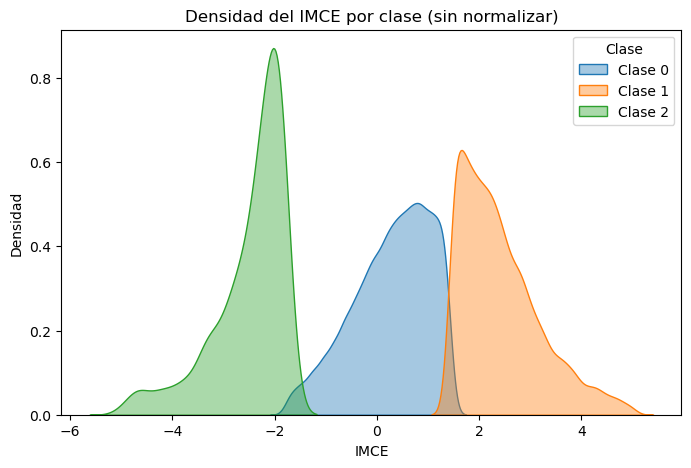

In [222]:
plt.figure(figsize=(8, 5))

for clase in sorted(df['imce_class'].unique()):
    subset = df[df['imce_class'] == clase]
    sns.kdeplot(subset['imce'], label=f'Clase {clase}', fill=True, alpha=0.4)

plt.title('Densidad del IMCE por clase (sin normalizar)')
plt.xlabel('IMCE')
plt.ylabel('Densidad')
plt.legend(title='Clase')
plt.show()

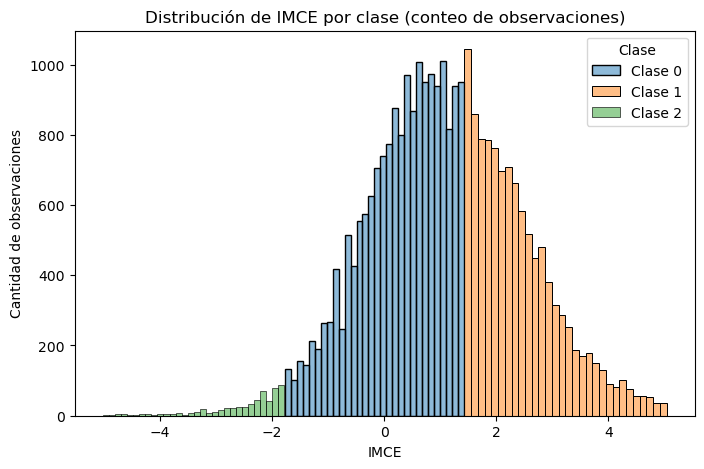

In [223]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

for clase in sorted(df['imce_class'].unique()):
    subset = df[df['imce_class'] == clase]
    sns.histplot(subset['imce'], label=f'Clase {clase}', bins=30, alpha=0.5, kde=False, stat='count')

plt.title('Distribución de IMCE por clase (conteo de observaciones)')
plt.xlabel('IMCE')
plt.ylabel('Cantidad de observaciones')
plt.legend(title='Clase')
plt.show()


### 6. Implemente un SEM completo usando la estructura propuesta en la Pregunta 4. En particular, estime un modelo donde los factores latentes explican el imce, junto con otras variables que existen en la base de datos. Ademas utilice otras variables relevantes de la base de datos para su modelo. Las variables a incluir en el modelo final deben tener sustento teorico y el modelo final debe optimizar el ajuste a los datos, en base a los criterios vistos en clase (TLI, CLI, RMSEA). Que puede concluir en base a sus resultados?

**R:** Después de inspeccionar las variables para explicar el IMCE, determinamos que, además de las clases latentes, las variables de actividad física, sexo, edad, educación de la madre y educación del padre son adecuadas para incluir en el modelo. Esto se concluye porque otras variables, como “vive padre” y “área”, fueron descartadas por no ser estadísticamente significativas, mientras que “vive madre” fue excluida debido a que su parámetro estimado fue muy bajo, indicando una contribución mínima al modelo.

Por otro lado, dentro de las variables que explican los factores latentes, observamos que eta1, o interés y aprendizaje, está compuesta por la educación del padre, la educación de la madre y si la madre trabaja, ya que estas variables reflejan habilidades y aspectos del entorno cognitivo y socioeconómico del niño. En cuanto a eta2, o expresión emocional, se consideraron variables como el sexo del niño, la edad, el área donde vive y la frecuencia de actividad física, dado que el sexo y la edad son variables demográficas básicas, el área refleja el contexto geográfico que puede influir en su estilo de vida, y la actividad física está relacionada con comportamientos saludables. 

Finalmente, eta3, o interacción cooperativa, está determinada por la presencia de la madre y el padre en el hogar, pues la convivencia con ambos es fundamental para entender el contexto familiar y emocional del niño. Al ajustar el modelo, se obtuvo un CFI de 0.72, indicando un ajuste moderado-bajo; el TLI de 0.67 también sugiere un ajuste bajo, mientras que el RMSEA de 0.074 se encuentra en un rango aceptable pero no óptimo. Estos resultados muestran que, aunque el modelo captura algunos aspectos relevantes, aún presenta limitaciones y podría beneficiarse de ajustes para mejorar su capacidad explicativa.

In [224]:
df.columns

Index(['sexo', 'edad', 'imce', 'vive_padre', 'vive_madre', 'sk1', 'sk2', 'sk3',
       'sk4', 'sk5', 'sk6', 'sk7', 'sk8', 'sk9', 'sk10', 'sk11', 'sk12',
       'sk13', 'act_fisica', 'area', 'educm', 'educp', 'madre_work',
       'imce_class'],
      dtype='object')

In [225]:
mod = """
#Measurement
eta1 =~ sk9 + sk10+ sk11+ sk12+ sk13 #Interes_Aprendizaje 
eta2 =~ sk1+ sk2+ sk3+ sk4+ sk8      #Expresion_Emocional
eta3 =~ sk5+ sk6                     #Interaccion_Cooperativa


#Structural
imce =~ eta1 + eta2 + eta3 + act_fisica + sexo + edad + educm + educp + madre_work 
eta1 ~ educm + educp + madre_work
eta2 ~ sexo + edad + area + act_fisica
eta3 ~ vive_madre + vive_padre

"""
#vive padre madre area out pq no son significativos
model_cfa = semopy.Model(mod);
out = model_cfa.fit(df);
print(out)

Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.016
Number of iterations: 79
Params: 1.379 1.237 1.087 1.296 1.917 1.636 1.816 1.561 1.116 0.703 1.046 -0.578 0.251 4.133 -2.759 -2.557 -0.322 -0.001 0.001 0.008 -0.014 -0.007 0.010 0.006 0.029 -0.016 1.113 17.096 10.476 11.134 0.070 0.010 0.062 0.081 0.878 0.243 0.097 0.584 0.205 0.446 0.705 0.241 0.205 0.169 0.161 0.353 0.571 0.278


In [226]:
model_cfa.inspect(mode='list', what="names", std_est=True)

,lval,op,rval,Estimate,Est. Std,Std. Err,z-value,p-value
0,eta1,~,imce,1.000000,0.731036,-,-,-
1,eta2,~,imce,0.702579,0.919474,0.014293,49.15458,0.0
2,eta3,~,imce,1.046246,0.766712,0.018289,57.205448,0.0
3,act_fisica,~,imce,-0.577659,-0.153668,0.0296,-19.515774,0.0
4,sexo,~,imce,0.251047,0.143067,0.013743,18.267365,0.0
5,edad,~,imce,4.132564,0.273123,0.129414,31.932952,0.0
6,educm,~,imce,-2.759390,-0.235380,0.085644,-32.21916,0.0
7,educp,~,imce,-2.557269,-0.212721,0.087081,-29.366699,0.0
8,madre_work,~,imce,-0.321890,-0.097112,0.023256,-13.841212,0.0
9,eta1,~,educm,-0.001265,-0.010840,0.00074,-1.710227,0.087224


In [227]:
# Obtener parámetros
params = model_cfa.inspect(mode='list', what='names', std_est=True)
params = pd.DataFrame(params)

# Definir patrones a excluir
excluir = ['^sk', '^eta']

# Filtrar filas que NO contengan esos patrones en lval o rval
filtro = ~params['lval'].str.contains('|'.join(excluir), regex=True) #& \
         #~params['rval'].str.contains('|'.join(excluir), regex=True)

params_filtrados = params[filtro]

# Mostrar resultado
display(params_filtrados[['lval', 'op', 'rval', 'Estimate', 'p-value']])

,lval,op,rval,Estimate,p-value
3,act_fisica,~,imce,-0.577659,0.0
4,sexo,~,imce,0.251047,0.0
5,edad,~,imce,4.132564,0.0
6,educm,~,imce,-2.759390,0.0
7,educp,~,imce,-2.557269,0.0
8,madre_work,~,imce,-0.321890,0.0
30,act_fisica,~~,act_fisica,1.113378,0.0
31,edad,~~,edad,17.096237,0.0
32,educm,~~,educm,10.475631,0.0
33,educp,~~,educp,11.134384,0.0


In [228]:
stats = calc_stats(model_cfa)
print("CFI:", stats['CFI'])
print("- - - - - - - - - - - - -")

print("TLI:", stats['TLI'])
print("- - - - - - - - - - - - -")
print("RMSEA:", stats['RMSEA'])

CFI: Value    0.720519
Name: CFI, dtype: float64
- - - - - - - - - - - - -
TLI: Value    0.674702
Name: TLI, dtype: float64
- - - - - - - - - - - - -
RMSEA: Value    0.074268
Name: RMSEA, dtype: float64


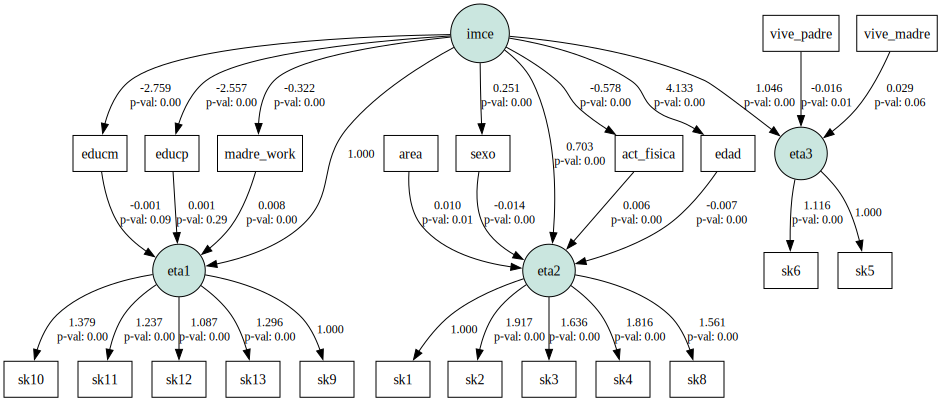

In [229]:
semopy.semplot(model_cfa, "semmodel.png")

### 7. Repita el analisis de la Pregunta 6 usando para cada submuestra generada a partir de las clases latentes obtenida en la pregunta 5. Reporte diferencias entre los parametros entre los distintos grupos (si existieran). Hay alguna ganancia de estimar el modelo por grupos versus el modelo general?  

**R:** Se ajustó el modelo SEM para cada subgrupo definido por los clusters de IMCE con el objetivo de evaluar si el ajuste del modelo varía según el estado nutricional: peso normal (cluster 0), sobrepeso (cluster 1) y bajo peso (cluster 2).

Para el grupo con peso normal, el modelo mostró un CFI de 0.718, un TLI de 0.671 y un RMSEA de 0.075, lo que indica un ajuste moderado, aunque no óptimo, manteniéndose dentro de rangos aceptables para modelos complejos. En el grupo de sobrepeso, el ajuste fue ligeramente mejor con un CFI de 0.724, TLI de 0.678 y RMSEA de 0.074, sugiriendo una mejor explicación del modelo para este subgrupo. Por último, el grupo de bajo peso presentó un CFI de 0.728, TLI de 0.683 y RMSEA de 0.072, evidenciando el mejor ajuste relativo entre los tres, aunque sigue siendo un ajuste moderado.

Estos resultados muestran que el modelo tiene un desempeño relativamente estable entre los diferentes grupos, con leves mejoras en los índices de ajuste en los grupos de sobrepeso y bajo peso en comparación con el grupo de peso normal. Sin embargo, en todos los casos, los índices sugieren un ajuste moderado, lo que podría indicar la necesidad de considerar variables adicionales o ajustar la estructura del modelo para mejorar su capacidad explicativa.

En conclusión, el análisis por clusters permite observar cómo la estructura latente se comporta de manera similar pero con pequeñas variaciones en función del estado nutricional, lo que aporta un enfoque más detallado para entender las diferencias en los factores que influyen en el IMCE según el perfil de peso.

In [230]:
# Filtrar los datos de acuerdo con los clusters de IMCE (de la Pregunta 5)
df_group0 = df[df['imce_class'] == 0]  # Cluster 0 (Peso normal)
df_group1 = df[df['imce_class'] == 1]  # Cluster 1 (Sobrepeso)
df_group2 = df[df['imce_class'] == 2]  # Cluster 2 (Peso bajo)

# Ajustar el modelo SEM para cada subgrupo usando el modelo de la Pregunta 6
model_group0 = semopy.Model(mod)  # Usar el mismo modelo de la Pregunta 6
out_group0 = model_group0.fit(df_group0)  # Ajuste para el Cluster 0
print("Resultados para Cluster 0 (Peso normal):")
print(out_group0)

model_group1 = semopy.Model(mod)  # Modelo para el Cluster 1 (Sobrepeso)
out_group1 = model_group1.fit(df_group1)  # Ajuste para el Cluster 1
print("Resultados para Cluster 1 (Sobrepeso):")
print(out_group1)

model_group2 = semopy.Model(mod)  # Modelo para el Cluster 2 (Peso bajo)
out_group2 = model_group2.fit(df_group2)  # Ajuste para el Cluster 2
print("Resultados para Cluster 2 (Peso bajo):")
print(out_group2)

# Comparar los resultados entre los subgrupos
stats_group0 = calc_stats(model_group0)
stats_group1 = calc_stats(model_group1)
stats_group2 = calc_stats(model_group2)

# Mostrar los índices de ajuste (CFI, TLI, RMSEA) para cada modelo
print("Grupo 0 (Peso normal) - CFI:", stats_group0['CFI'], "TLI:", stats_group0['TLI'], "RMSEA:", stats_group0['RMSEA'])
print("Grupo 1 (Sobrepeso) - CFI:", stats_group1['CFI'], "TLI:", stats_group1['TLI'], "RMSEA:", stats_group1['RMSEA'])
print("Grupo 2 (Peso Bajo) - CFI:", stats_group2['CFI'], "TLI:", stats_group2['TLI'], "RMSEA:", stats_group2['RMSEA'])

Resultados para Cluster 0 (Peso normal):
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.031
Number of iterations: 80
Params: 1.373 1.234 1.088 1.256 1.907 1.700 1.900 1.556 1.134 0.685 1.022 -0.523 0.246 3.884 -2.726 -2.536 -0.308 -0.001 -0.001 0.006 -0.016 -0.006 0.012 0.005 0.024 -0.013 1.146 16.784 10.467 11.163 0.069 0.010 0.059 0.080 0.881 0.245 0.098 0.569 0.200 0.439 0.697 0.242 0.199 0.167 0.154 0.341 0.547 0.283
Resultados para Cluster 1 (Sobrepeso):
Name of objective: MLW
Optimization method: SLSQP
Optimization successful.
Optimization terminated successfully
Objective value: 1.017
Number of iterations: 79
Params: 1.397 1.250 1.102 1.371 1.909 1.519 1.669 1.521 1.091 0.737 1.086 -0.663 0.246 4.571 -2.766 -2.573 -0.349 -0.002 0.003 0.013 -0.006 -0.007 0.005 0.009 0.032 -0.023 1.056 17.449 10.514 11.063 0.071 0.011 0.067 0.081 0.872 0.241 0.095 0.608 0.211 0.460 0.717 0.239 0.215 0.171 0.174 0.3